# Hyperparameter Tuning — Optuna sobre LightGBM
60 trials de búsqueda bayesiana (TPE) con 3-fold CV.
Compara el modelo tuneado contra el baseline de `train_06.py`.

In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.models.tune_07 import main, plot_tuning_history, N_TRIALS
from src.models.train_06 import load_data, evaluate_on_test, plot_roc_pr, MODELS_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
from sklearn.model_selection import train_test_split
sns.set_theme(style='whitegrid')
%matplotlib inline
RANDOM_STATE = 42

  from .autonotebook import tqdm as notebook_tqdm


## 1. Ejecutar tuning

── Cargando features ──
Dataset: 992,931 filas × 30 features | churn rate: 6.39%

── Optimización Optuna (60 trials × 3-fold CV) ──


Best trial: 43. Best value: 0.985798: 100%|██████████| 60/60 [46:21<00:00, 46.36s/it]



Mejor AUC CV : 0.98580
Mejores parámetros:
  n_estimators             : 705
  learning_rate            : 0.01916371334448858
  num_leaves               : 178
  max_depth                : 10
  min_child_samples        : 148
  subsample                : 0.74874456350306
  colsample_bytree         : 0.7148534246152031
  reg_alpha                : 0.00018031171684553812
  reg_lambda               : 0.771762300394068

── Entrenando modelo final con mejores parámetros ──

── Evaluando en test set ──

═══════════════════════════════════════════════════════
TEST — LightGBM baseline
  ROC-AUC   : 0.9853
  PR-AUC    : 0.8549
  F1 (thr=0.89): 0.7599
              precision    recall  f1-score   support

     Renewal      0.982     0.986     0.984    185893
       Churn      0.779     0.741     0.760     12694

    accuracy                          0.970    198587
   macro avg      0.881     0.864     0.872    198587
weighted avg      0.969     0.970     0.970    198587


════════════════════════

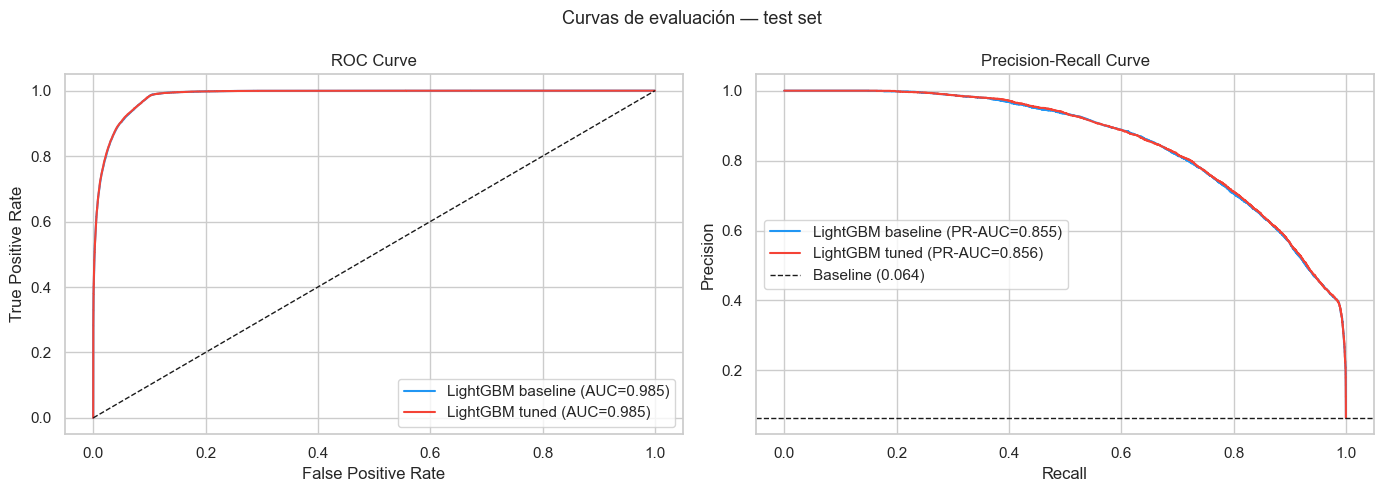

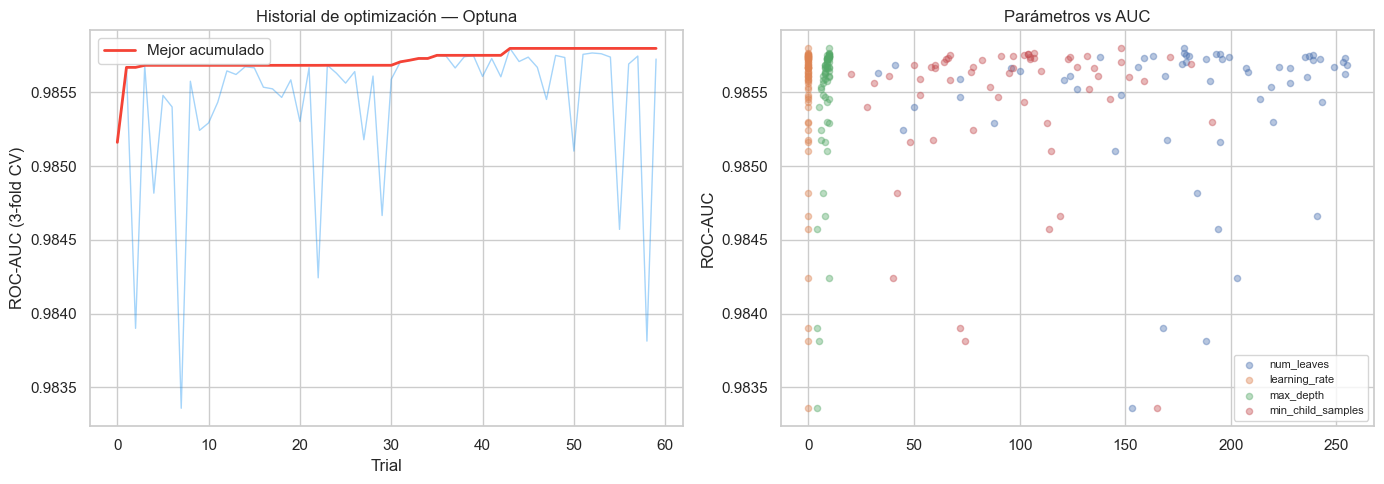

In [2]:
tuned_model, study = main()

## 2. Historial de optimización

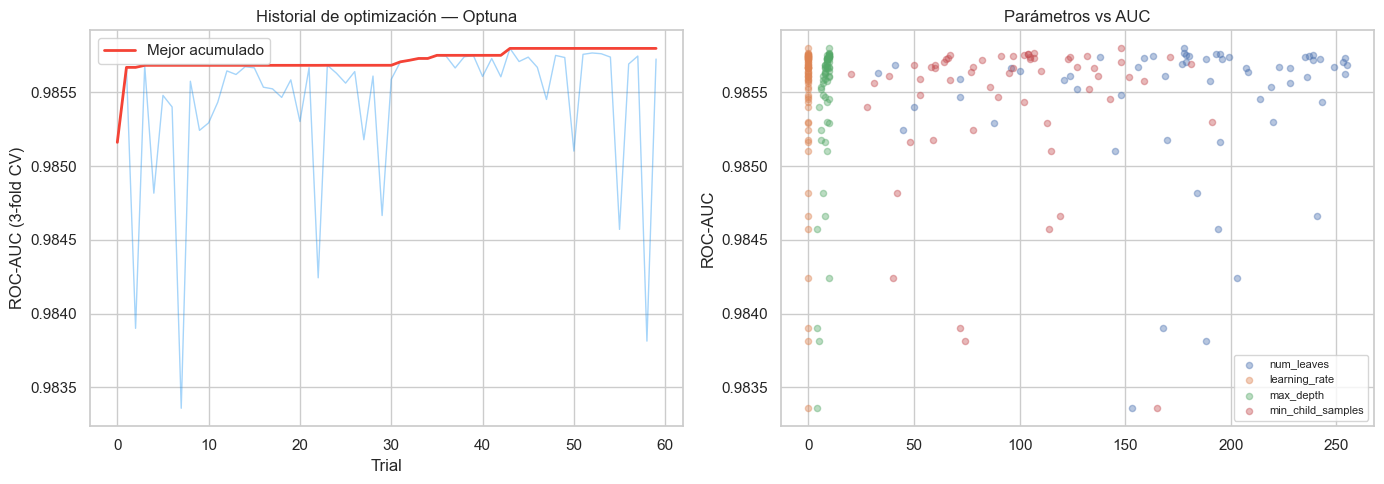

In [3]:
plot_tuning_history(study)

## 3. Mejores parámetros

In [4]:
trials = study.trials_dataframe().sort_values('value', ascending=False)
print(f'Mejor AUC CV: {study.best_value:.5f}')
print('\nMejores parámetros:')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')
trials.head(10)

Mejor AUC CV: 0.98580

Mejores parámetros:
  n_estimators             : 705
  learning_rate            : 0.01916371334448858
  num_leaves               : 178
  max_depth                : 10
  min_child_samples        : 148
  subsample                : 0.74874456350306
  colsample_bytree         : 0.7148534246152031
  reg_alpha                : 0.00018031171684553812
  reg_lambda               : 0.771762300394068


,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,params_reg_alpha,params_reg_lambda,params_subsample,state
43,43,0.985798,2026-04-25 17:22:03.257310,2026-04-25 17:23:04.551172,0 days 00:01:01.293862,0.714853,0.019164,10,148,705,178,0.000180,0.771762,0.748745,COMPLETE
52,52,0.985767,2026-04-25 17:29:56.768951,2026-04-25 17:30:53.008925,0 days 00:00:56.239974,0.701241,0.023148,10,107,645,178,0.000470,1.583204,0.702524,COMPLETE
53,53,0.985762,2026-04-25 17:30:53.009610,2026-04-25 17:31:51.345469,0 days 00:00:58.335859,0.694333,0.023699,10,104,646,193,0.000329,1.379162,0.698187,COMPLETE
51,51,0.985758,2026-04-25 17:28:54.991944,2026-04-25 17:29:56.768262,0 days 00:01:01.776318,0.703904,0.019350,10,104,661,195,0.000565,0.294928,0.702918,COMPLETE
35,35,0.985751,2026-04-25 17:12:16.691368,2026-04-25 17:13:39.185149,0 days 00:01:22.493781,0.711664,0.012995,10,67,718,239,0.000660,0.037176,0.717699,COMPLETE
48,48,0.985751,2026-04-25 17:26:46.603962,2026-04-25 17:27:35.362826,0 days 00:00:48.758864,0.674556,0.020884,9,102,627,179,0.000475,0.637247,0.729193,COMPLETE
39,39,0.985749,2026-04-25 17:17:25.471802,2026-04-25 17:18:27.195927,0 days 00:01:01.724125,0.770116,0.018561,10,132,674,180,0.000107,0.272265,0.748984,COMPLETE
57,57,0.985746,2026-04-25 17:33:20.638714,2026-04-25 17:34:12.408238,0 days 00:00:51.769524,0.691585,0.020398,10,91,598,163,0.000195,0.540672,0.782169,COMPLETE
36,36,0.985746,2026-04-25 17:13:39.185823,2026-04-25 17:14:55.841152,0 days 00:01:16.655329,0.715859,0.013522,10,97,706,237,0.000572,0.073833,0.716462,COMPLETE
38,38,0.985742,2026-04-25 17:16:19.640959,2026-04-25 17:17:25.471060,0 days 00:01:05.830101,0.761401,0.018088,10,124,676,235,0.000489,0.252339,0.741772,COMPLETE


## 4. Importancia de parámetros

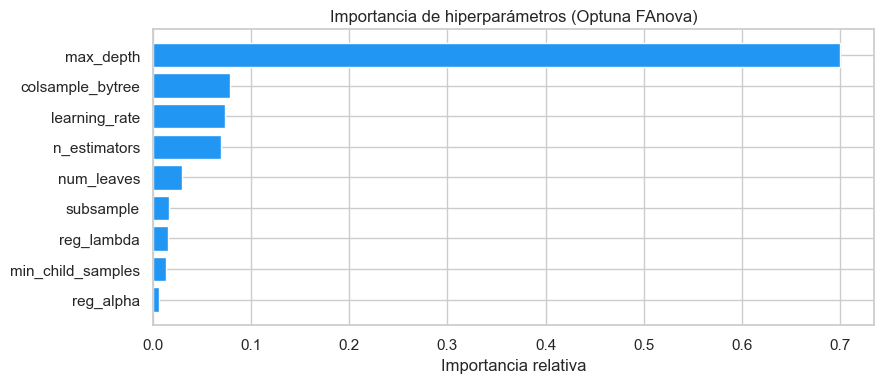

In [5]:
importances = optuna.importance.get_param_importances(study)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(importances.keys())[::-1], list(importances.values())[::-1],
        color='#2196F3', edgecolor='white')
ax.set_title('Importancia de hiperparámetros (Optuna FAnova)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

## 5. Cargar modelos y comparar en test

Dataset: 992,931 filas × 30 features | churn rate: 6.39%

═══════════════════════════════════════════════════════
TEST — LightGBM baseline
  ROC-AUC   : 0.9853
  PR-AUC    : 0.8549
  F1 (thr=0.89): 0.7599
              precision    recall  f1-score   support

     Renewal      0.982     0.986     0.984    185893
       Churn      0.779     0.741     0.760     12694

    accuracy                          0.970    198587
   macro avg      0.881     0.864     0.872    198587
weighted avg      0.969     0.970     0.970    198587


═══════════════════════════════════════════════════════
TEST — LightGBM tuned
  ROC-AUC   : 0.9854
  PR-AUC    : 0.8561
  F1 (thr=0.90): 0.7605
              precision    recall  f1-score   support

     Renewal      0.982     0.987     0.984    185893
       Churn      0.795     0.729     0.760     12694

    accuracy                          0.971    198587
   macro avg      0.888     0.858     0.872    198587
weighted avg      0.970     0.971     0.970    1985

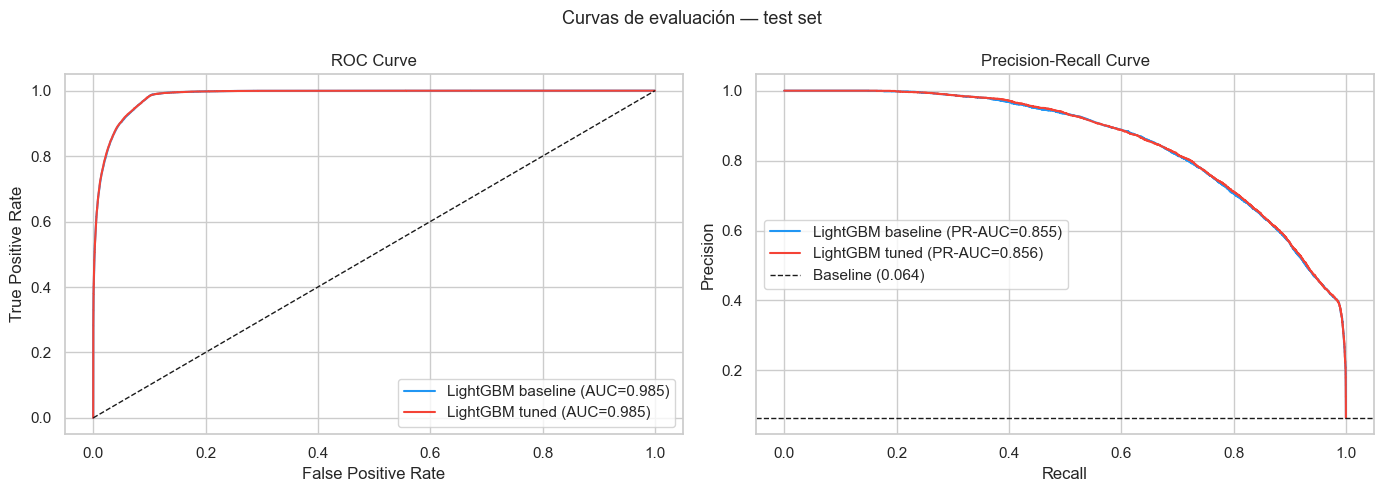

In [6]:
X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

baseline = joblib.load(MODELS_DIR / 'best_model.joblib')['model']
tuned    = joblib.load(MODELS_DIR / 'lgbm_tuned.joblib')['model']

results = [
    evaluate_on_test('LightGBM baseline', baseline, X_test, y_test),
    evaluate_on_test('LightGBM tuned',    tuned,    X_test, y_test),
]
plot_roc_pr(results, y_test)